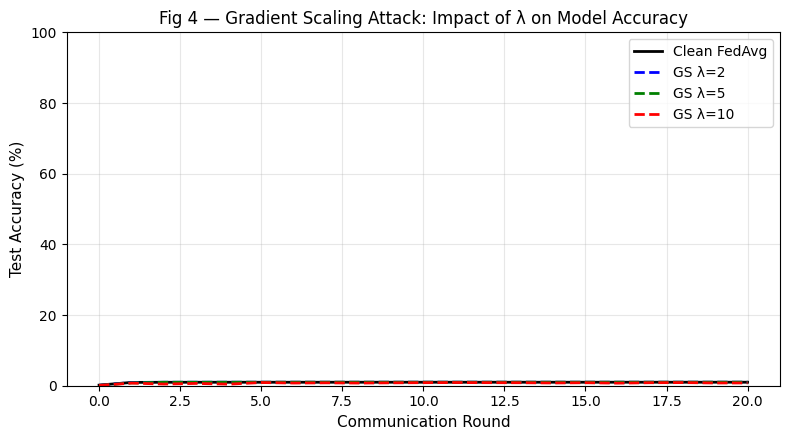

✓ fig4_grad_scaling.png saved


In [10]:
gs2  = pd.read_csv(RESULTS + "grad_scale_lam2.csv")
gs5  = pd.read_csv(RESULTS + "grad_scale_lam5.csv")
gs10 = pd.read_csv(RESULTS + "grad_scale_lam10.csv")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(baseline['round'], baseline['accuracy'],  'k-',  lw=2, label='Clean FedAvg')
ax.plot(gs2['round'],      gs2['accuracy'],      'b--', lw=2, label='GS λ=2')
ax.plot(gs5['round'],      gs5['accuracy'],      'g--', lw=2, label='GS λ=5')
ax.plot(gs10['round'],     gs10['accuracy'],     'r--', lw=2, label='GS λ=10')

ax.set_xlabel('Communication Round', fontsize=11)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_title('Fig 4 — Gradient Scaling Attack: Impact of λ on Model Accuracy', fontsize=12)
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(FIGURES + "fig4_grad_scaling.png", dpi=150)
plt.show()
print("✓ fig4_grad_scaling.png saved")

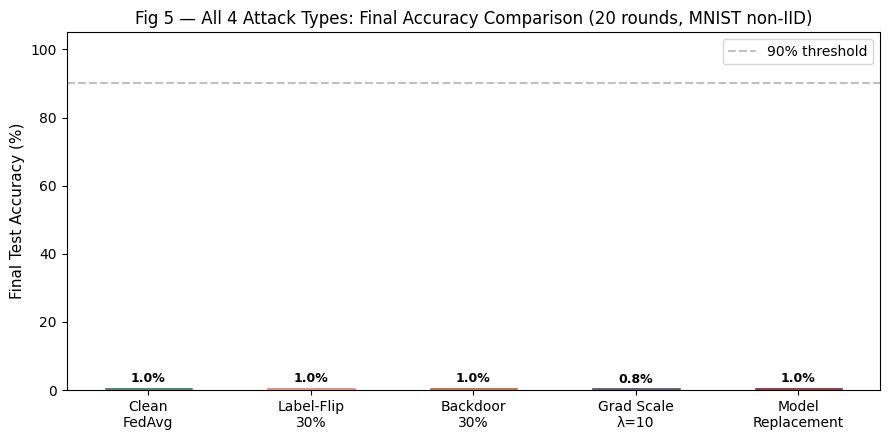

✓ fig5_attack_table.png saved


In [11]:
import pandas as pd

RESULTS = "../../experiments/results/"
FIGURES = "../../report/figures/"

# Load all CSVs
baseline = pd.read_csv(RESULTS + "baseline_mnist.csv")
lf30     = pd.read_csv(RESULTS + "label_flip_f30.csv")
bd30     = pd.read_csv(RESULTS + "backdoor_f30.csv")
gs10     = pd.read_csv(RESULTS + "grad_scale_lam10.csv")
mr       = pd.read_csv(RESULTS + "model_replacement.csv")

summary  = pd.read_csv(RESULTS + "attacks_summary.csv")

labels = ['Clean\nFedAvg', 'Label-Flip\n30%', 'Backdoor\n30%',
          'Grad Scale\nλ=10', 'Model\nReplacement']

accs = [
    baseline['accuracy'].iloc[-1],
    lf30['accuracy'].iloc[-1],
    bd30['accuracy'].iloc[-1],
    gs10['accuracy'].iloc[-1],
    mr['accuracy'].iloc[-1],
]
colors = ['#2d6a4f', '#e07a5f', '#c05621', '#3d405b', '#81171b']

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(labels, accs, color=colors, edgecolor='white', width=0.55)
ax.axhline(90, color='gray', linestyle='--', alpha=0.5, label='90% threshold')

for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Final Test Accuracy (%)', fontsize=11)
ax.set_title('Fig 5 — All 4 Attack Types: Final Accuracy Comparison (20 rounds, MNIST non-IID)', fontsize=12)
ax.set_ylim(0, 105); ax.legend()

plt.tight_layout()
plt.savefig(FIGURES + "fig5_attack_table.png", dpi=150)
plt.show()
print("✓ fig5_attack_table.png saved")